Make sure to run this from a folder where you will only have this script and the 'input' folder with the .cel file. In other words, say you run it from the folder "Dr_Probe_simulations", inside of this folder you must have this code and another folder named "input" containing the ".cel" file

I have a continuation for rotated simulated image where I basically overlap the two images and plot points to compare how far they are from each other. If you would like that part or think it could be relevant, let me know.

Thinking of an automatic way to look at figures, I was not able to dedicate much time to an implementation where I could retrieve the simulated image, crop it, resize it, and then compare it with experimental image. So I have it hard coded in a way. For my example here, I just have them correctly sized and cropped before, then I just ensure they are the same size (with a fixed number resizing), then I plot it for comparison. On the evaluate_model function you also have the option to use the rotated image instead of the one obtained directly through experiment.

The rotate_image function still needs some work, like ensuring that the comparison is capturing the same area that the non-ratated image is (I believe it should be). There is a black (blank) void that remains when you rotate the image, it is like you rotate the photo inside of a frame, so you still can see the photo but you can also see the back of the frame. I want to find a way that the rotated image does not show that "black frame" in the back, just the purely rotated image, but I am still not sure how to do that.

Other than that, I think the code does what is intended to do. 

In [9]:
#%% 1.1) Import modules and set constants
#%reset -f
#Import important modules
import drprobe as drp
import numpy as np
import os
import shutil
import sys 
#sys.path.append(r'')
from random import randint
import time
from skimage.metrics import structural_similarity as ssim
from PIL import Image
import cv2
from skimage.feature import blob_dog, blob_log
from skimage.transform import rotate
import matplotlib.pyplot as plt

class DrProbe():

    def __init__(self):


        # Initialize constant parameters
        self.ht = 300;                   # High tension is 300 kV
        self.nx = 850; self.ny = 850;         # All images, wavefunctions, etc. will be 512 x 512 pixels
        self.nz = 100;                 # The structures will be cut into 100 slices
        self.dwf = True; self.buni = 0.005;   # Debye-Wallar factor on and set B = 0.5 Ang^2
        #dwf = True; buni = 0.000;   # Debye-Wallar factor on and set B = 0.5 Ang^2
        self.absorb = True;              # Apply built-in absorptive form factors
        self.output = True;              # Give chatty output during simulations
        ##Cs = -13000
        #Cs = -13000                 # Cs = -9 um, enter in nm
        #C5 = 5000000                # C5 = 5 mm, enter in nm
        self.Cs = -9000                 # Cs = -9 um, enter in nm
        self.C5 = 5000000                # C5 = 5 mm, enter in nm
        self.msa_prm_gen = drp.msaprm.MsaPrm()
        self.wav_prm_gen = drp.wavimgprm.WavimgPrm()

    def inputs(self,input_dir_path,output_dir_path, defoci_vals):

        #%% 1.2) Specify input and output directories

        # Input directory containing .cel files to be simulated
        #input_dir = r'/home/thiago/Desktop/Argonne/ingrained_test/Cif_model_examples/Cif_model_examples/test/test_new_script/input'
        self.input_dir = r'{}'.format(input_dir_path)

        # Output directory where simulations should be saved
        #output_dir = r'/home/thiago/Desktop/Argonne/ingrained_test/Cif_model_examples/Cif_model_examples/test/test_new_script/output'
        self.output_dir = r'{}'.format(output_dir_path)

        # Create the full path to the SimulationCheck directory
        output_check_dir = os.path.join(self.output_dir, 'SimulationCheck')

        # Create the directory and any intermediate directories if they don't exist
        os.makedirs(output_check_dir, exist_ok=True)


        # output_check_dir = os.path.join(output_dir, 'SimulationCheck')
        # if os.path.isdir(output_check_dir):
        #     pass # Do nothing if exists
        # else:
        #     os.mkdir(output_check_dir) # Make directory otherwise

        # Range of defocus in nm. Positive values indicate overfocus
        #defoci = [-5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15]
        #defoci = [-12, -10, -8, -6, -4, 0, 4, 6, 8, 10, 12]
        #defoci = [-10,-9,-8,-7,-6,-5,-4,-3,-2,-1, 0]
        #defoci = [5]
        #defoci = [600]

        self.defoci = defoci_vals
        
        # ex: defoci = [5, 8, 10, 12, 14, 16, 20, 22, 24],
        # where defoci_vals = [5, 8, 10, 12, 14, 16, 20, 22, 24]

        #defoci = [6]
        #defoci = [1,2,3,4,0]

        #input_file = str(input(r'/Users/ramon/Dropbox/Users/Ramon_Manzorro/Big_Data_HDR/Data/Image_simulations/input_test/pt-ceo2-thickness.cif'))

        #drp.commands.cellmuncher(cif_file=input, output=file='pt-ceo2-thickness.cel')

        # Read lattice parameters from cel filed

        self.cel_files = [f for f in os.listdir(input_dir_path) if f.endswith(".cel")]

        #if len(cel_files) != 1:
        #    raise ValueError("Expected one .cel file in input_dir_path, found {}".format(len(cel_files)))

        cel_file_path = os.path.join(input_dir_path, self.cel_files[0])

        self.a, self.b, self.c = np.genfromtxt(cel_file_path, skip_header=1, skip_footer=1, usecols=(1, 2, 3))[0]
        #self.a, self.b, self.c= np.genfromtxt("{}".format(self.input_dir), skip_header=1, skip_footer=1, usecols=(1, 2, 3))[0]
        #nz = int(round(c*6)) # Determine number of slices given that we would like 40 slices every nm


        #%% 1.3) Initialize Parameter Files

        # Initialize general MSA Parameter File
        #self.msa_prm_gen = drp.msaprm.MsaPrm()
        self.msa_prm_gen.wavelength = 0.0019687482               # Electron wavelength in nm
        self.msa_prm_gen.focus_spread = 4                        # Focus half-spread in nm
        self.msa_prm_gen.tilt_x = 0
        self.msa_prm_gen.tilt_y = 0
        self.msa_prm_gen.h_scan_frame_size = self.a                   # This is the size of the cel in nm
        self.msa_prm_gen.v_scan_frame_size = self.b 
        self.msa_prm_gen.scan_columns = self.nx                       # Unsure if matters but consistent with image
        self.msa_prm_gen.scan_rows = self.ny  
        self.msa_prm_gen.temp_coherence_flag = 0                 # Turn off temporal coherence calculation (STEM only)
        self.msa_prm_gen.spat_coherence_flag = 0                 # Turn off spatial coherence calculation (STEM only)
        self.msa_prm_gen.slice_files = ''                        # String of slice file, will be set iteratively later
        self.msa_prm_gen.number_of_slices = self.nz                   # Load one slice at a time
        self.msa_prm_gen.det_readout_period = 0                  # No detector effects included.
        self.msa_prm_gen.tot_number_of_slices = self.nz               # Each structure contains 155 slices
        self.msa_prm_gen.aberrations_dict = {1: (0, 0),          # Defocus of 0 nm standard, will be adjusted iteratively later
                                        5: (self.Cs, 0),         # Cs = -13 um
                                        11: (self.C5, 0)}        # C5 = 5 mm         
        #self.msa_prm_gen.save_msa_prm(r'home/thiago/Desktop/Argonne/ingrained_test/Cif_model_examples/Cif_model_examples/test/test_new_script/output/init_prm/MsaPrm_parallel_Initialized.prm') # Save the initailized MSA prm file
        self.msa_prm_gen.save_msa_prm(os.path.join(output_dir_path, 'init_prm', 'MsaPrm_parallel_Initialized.prm'))

        # Initizliae general WavImg Parameter File
        #self.wav_prm_gen = drp.wavimgprm.WavimgPrm()
        self.wav_prm_gen.high_tension = self.ht                       # Set HT to 300 kV
        self.wav_prm_gen.wave_dim = (self.nx,self.ny)                      # Pixel dimensions of wave are nx by ny
        self.wav_prm_gen.wave_sampling = (self.a/self.nx, self.b/self.ny)            # Pixel size is width of cell divided by pixel dimensions
        self.wav_prm_gen.output_format = 0                       # Output TEM image
        self.wav_prm_gen.output_dim = (self.nx,self.ny)                    # Pixel dimensions of image are nx by ny
        self.wav_prm_gen.coherence_model = 2                     # Explicit TCC calculation
        self.wav_prm_gen.temp_coherence = (1,4)                  # Turn on temporal coherence. Focal spread half-width of 4 nm
        self.wav_prm_gen.spat_coherence = (1,0.2)                # Turn on spatial coherence. 2nd number = Beam convergence half angle of 0.2 mrad
        self.wav_prm_gen.mtf = (0, 1, r'E:\MTF-US2k-300.mtf')    # Turn off detector MTF effect. Calculation scale of the mtf = (sampling rate experiment)/(sampling rate simulation)
        self.wav_prm_gen.vibration = (1, 0.05, 0.05, 0)          # 50 pm isotropic vibration applied.
        self.wav_prm_gen.oa_radius = 250                          # Objective aperture essentially out, set to 250 mrad
        self.wav_prm_gen.aberrations_dict = {1: (0, 0),          # Defocus of 0 nm standard, will be adjusted iteratively later
                                        5: (self.Cs, 0),         # Cs = -13 um
                                        11: (self.C5, 0)}        # C5 = 5 mm    
        #self.wav_prm_gen.save_wavimg_prm(r'home/thiago/Desktop/Argonne/ingrained_test/Cif_model_examples/Cif_model_examples/test/test_new_script/output/init_prm/WavPrm_Initialized.prm') # Save the initailized WavImg prm file)
        self.wav_prm_gen.save_wavimg_prm(os.path.join(output_dir_path, 'init_prm', 'MsaPrm_parallel_Initialized.prm'))
    
    
    def run_dr_probe(self,input_dir_path,output_dir_path):
        start = time.time()
        for self.cel_file in os.listdir(self.input_dir):   
            #self.cel_file=self.input_dir
        #for cel_file in os.listdir(input_dir):                          # For every structure in the input directory
        
            # Set-up parent directory for this structure
            self.structure_name = self.cel_file.strip('.cel')                                     # Remove the file extension to isolate the structure name
            self.structure_dir = os.path.join(output_dir_path, self.structure_name)                    # Name of directory for this structure, to be within the output directory
            os.mkdir(self.structure_dir)                                                     # Create structure's directory with name specified above


            ## 2.1) Create back-up of cel file in output directory
            # Set-up cel sub-directory
            self.structure_cel_dir = os.path.join(self.structure_dir, 'cel')                      # Set up name of cel sub-directory for this structure
            os.mkdir(self.structure_cel_dir)                                                 # Create cel directory with name specified above
            self.cel_original = r'"{}"'.format(os.path.join(input_dir_path, self.cel_file))            # Name of full directory to original cel file
            self.cel_copy = r'"{}"'.format(os.path.join(self.structure_cel_dir, self.cel_file))        # The r'"{}"' formatting is necessary to enclose the path in double quotes.
            
            #cel_file= r'/Users/ramon/Dropbox/Users/Ramon Manzorro/Big Data HDR/Data/Simulations/pt-1a-ceo2-111/input/pt-1a-ceo2-111.cel'
            
        #    # Create back-up cel
        #    drp.commands.cellmuncher(cel_original, cel_copy, 
        #                             output=True)                                      # Save the cel file in the copy directory
        #    
            
            
            ## 2.2) Slice cel and save slices in \slc directory
            # Set-up slice sub-directory
            self.structure_slc_dir = os.path.join(self.structure_dir, 'slc')                      # Name of directory for this structure's slices
            os.mkdir(self.structure_slc_dir)                                                 # Create the structure's slice directory
            self.slice_name = self.structure_name + '_slc'                                        # The r'"{}"' formatting is unnecessary since the path doesn't contain spaces.
            self.slice_path_and_name = os.path.join(self.structure_slc_dir,self.slice_name)
            
            ## slice cel
            drp.commands.celslc(self.cel_original, self.slice_path_and_name,                      # Create the slices and save them in the slice directory
                            self.ht, self.nx, self.ny, self.nz, 
                            absorb=self.absorb, dwf=self.dwf, buni=self.buni, pot=True,
                            output=True)
            
            ## 2.3) Perform multislice simulation
            # Parameter initialization
            self.structure_prm_dir = os.path.join(self.structure_dir, 'prm')                      # Set up name of parameter (or 'prm') sub-directory for this structure
            os.mkdir(self.structure_prm_dir)                                                 # Create parameter directory with name specified above
            self.msa_prm = self.msa_prm_gen                                                       # Load general parameter file to be edited
            self.msa_prm.slice_files = self.slice_path_and_name                                   # Specify location of phase gratings generated in section 2.2
            self.msa_prm_name = 'MsaPrm_'+self.structure_name+'.prm'                              # Name the MSA parameter file to be saved
            self.msa_prm_path_and_name = os.path.join(self.structure_prm_dir, self.msa_prm_name)       # Path location to where the MSA parameter file should be saved 
            self.msa_prm.save_msa_prm(self.msa_prm_path_and_name)                                 # Save the parameter file with the slice locations
            
            # Set-up wave function sub-directory
            self.structure_wav_dir = os.path.join(self.structure_dir, 'wav')                      # Set up name of wave function (or 'wav') sub-directory for this structure
            os.mkdir(self.structure_wav_dir)                                                 # Create wave function directory with name specified above
            self.wav_path = os.path.join(self.structure_wav_dir,self.structure_name)                   # Specify name (and path) of output wavefunction
            
            # Calculate exit surface wavefunction
            drp.commands.msa(self.msa_prm_path_and_name, self.wav_path,                           # Calculates the exit wavefunction and saves it in wav_path
                            ctem = True, output = True, 
                            silent = False)
            
            
            ## 2.4) Generate simulated images
            # Parameter initialization
            self.wav_prm = self.wav_prm_gen                                                       # Load general wav parameter file for image simulation
            self.wav_prm.wave_files = self.wav_path + '_sl' + str(self.nz) + '.wav'                    # Name of wave file and location after full multislice simulation (if nz bigger than or equal to 100) 
            #wav_prm.wave_files = wav_path + '_sl0' + str(nz) + '.wav'         #Use this if nz lower than 100           # Name of wave file and location after full multislice simulation (if nz smaller than 100)
            self.wav_prm_name = 'WavPrm_'+self.structure_name+'.prm'                              # Set name of wave paramter file
            self.wav_prm_path_and_name = os.path.join(self.structure_prm_dir, self.wav_prm_name)       # Path location to where the wav parameter file should be saved
            self.wav_prm.save_wavimg_prm(self.wav_prm_path_and_name)                              # Save the parameter file with the slice locations
            
            # Set-up image sub-directory
            self.structure_img_dir = os.path.join(self.structure_dir, 'img')                      # Set up name of image (or 'img') sub-directory for this structure
            os.mkdir(self.structure_img_dir)                                                 # Create image function directory with name specified above
            
            # Simulate images
            for defocus in self.defoci:
                    # Specify name (img_name) of path (output_img) of output image
                    if self.nz >= 100:
                        self.img_name = self.structure_name+'_'+ str(self.nz)+'slc_' +str(self.nx)+'x'+str(self.ny)+'_'+str(defocus)+'nmDefocus'+'.dat' # if nz bigger than or equal to 100 
                    else:
                        
                        self.img_name = self.structure_name+'_'+ str(self.nz)+'slc_0' +str(self.nx)+'x'+str(self.ny)+'_'+str(defocus)+'nmDefocus'+'.dat' # if nz smaller than 100
                    
                    self.output_img = os.path.join(self.structure_img_dir,self.img_name)
                    
                    # Calculate image
                    drp.commands.wavimg(self.wav_prm_path_and_name, self.output_img, 
                                        foc = defocus,
                                        sil = False, output=True)
                    
                    
                    # Save every 1 in 10 images randomly for diagnostics
                    #if randint(0,100) > 90:
                        #shutil.copyfile(output_img, os.path.join(output_check_dir,img_name))
            
            ## 2.5) Clean up slice directory
            # Delete slice sub-directory to save space
            try:
                shutil.rmtree(self.structure_slc_dir)
            except OSError as e:
                print ("Error: %s - %s." % (e.filename, e.strerror))


                
            end = time.time()
            print(end - start)
        
    def figure_generation(self,input_dir_img):
        #self.input_dir = input_dir_img
        output_folder = 'defocus_images'  # Name of the folder to save the images
        #/home/thiago/Desktop/Argonne/ingrained_test/Cif_model_examples/Cif_model_examples/test/test_new_script/output/Pt_6layer_modified/img'
        # Create the output folder if it doesn't exist
        os.makedirs(output_folder, exist_ok=True)

        for dat_file in os.listdir(input_dir_img):
            if dat_file.endswith(".dat") and not dat_file.startswith("._"):
                self.img_file_name = dat_file.strip('.dat')
                self.dat_file_path = os.path.join(input_dir_img, dat_file)
                self.dat_file_data = np.fromfile(self.dat_file_path, dtype=np.float32)
                
                self.dat_file_data_r = np.reshape(self.dat_file_data, (850, 850))
                self.scaled = self.dat_file_data_r * 255  # Scale the data to the range of 0-255
               # plt.axis('off')  # Turn off the axis; optional. Depends on your preference
                plt.imshow(self.scaled, cmap='gray')
                plt.title(self.img_file_name)  # Set the title of the figure
                self.save_path = os.path.join(output_folder, f"{self.img_file_name}.png")
                plt.savefig(self.save_path,bbox_inches='tight', pad_inches=0)  # Save the figure as a PNG image
                plt.show() # Remove this line if you do not want the output figures to be shown 
                plt.close()  # Close the current figure





    def scale_pixels(self,img, mode=None):
            """
            Select a pixel scaling technique

            Args:
                mode: (string) pixel scaling technique
                rescale    :  stretch the pixel intensities so to fill the 
                                range from 0 to 1 (float64)
                center     :  enforce zero mean, unit variance (float64)
                grayscale  :  stretch the pixel intensities so to fill the 
                                range from 0 to 255 (uint8)

            Returns:
                A numpy array (either float64 or uint8) of the scaled image.
            """
            img = img.astype(np.float64)
            if mode == None:
                return img
            elif mode == "rescale":
                return ((img - img.min()) / (img.max() - img.min()) + 1e-16).astype(np.float64)
            elif mode == "center":
                return ((img - img.mean()) / (img.std())).astype(np.float64)
            elif mode == "grayscale":
                return (255 * (img - img.min()) / (img.max() - img.min()) + 1e-16).astype(
                    np.uint8
            )

    def score_ssim(self,img1, img2):
            """
            Compute the mean structural similarity index between two images

            Args:
                    img1, img2: (ndarray) images

            Return:
                    1 - the mean structural similarity index (i.e. ΔSSIM)
            """

            #data_range = 255  # Dynamic range of pixel values in typical images

            img1 = self.scale_pixels(img1, mode="rescale")  # You need to define the scale_pixels function
            img2 = self.scale_pixels(img2, mode="rescale")
            im_max, im_min = max(img1.max(), img2.max()), min(img1.min(), img2.min())
            return 1 - ssim(img1, img2, data_range=im_max - im_min)  # You need to import the ssim function



    def rotate_figure(self,crp_exp_img, dr_probe_img):


        experimental_img = crp_exp_img
        simulated_img = dr_probe_img


        # Detect blobs in the experimental image using Difference of Gaussian (DoG)
        experimental_blobs = blob_dog(experimental_img, max_sigma=30, threshold=0.1)

        # Detect blobs in the simulated image using Difference of Gaussian (DoG)
        simulated_blobs = blob_dog(simulated_img, max_sigma=30, threshold=0.1)

        # Plot the images with detected atom positions
        plt.figure(figsize=(10, 5))


        # Detect blobs in the experimental image using Difference of Gaussian (DoG)
        experimental_blobs = blob_dog(experimental_img, max_sigma=30, threshold=0.1)
        experimental_central_point = np.mean(experimental_blobs, axis=0)[:2].astype(int)

        # Detect blobs in the simulated image using Difference of Gaussian (DoG)
        simulated_blobs = blob_dog(simulated_img, max_sigma=30, threshold=0.1)
        simulated_central_point = np.mean(simulated_blobs, axis=0)[:2].astype(int)

        # Calculate the rotation angle to align the central points
        angle = np.arctan2(experimental_central_point[1] - simulated_central_point[1],
                        experimental_central_point[0] - simulated_central_point[0])

        # Rotate the simulated image
        rotated_simulated_img = rotate(simulated_img, np.degrees(angle))

        # Plot the images with detected atom positions and overlap
        plt.figure(figsize=(12, 6))

        # Plot experimental image
        plt.subplot(1, 2, 1)
        plt.imshow(experimental_img, cmap='gray')
        plt.title('Experimental Image')
        for blob in experimental_blobs:
            y, x, _ = blob
            plt.plot(x, y)  # Red points for experimental atoms

        # Plot simulated image
        plt.subplot(1, 2, 2)
        plt.imshow(simulated_img, cmap='gray')
        plt.title('Simulated Image')
        for blob in simulated_blobs:
            y, x, _ = blob
            plt.plot(x, y, 'go', markersize=5)  # Green points for simulated atoms

        # Plot rotated simulated image
        plt.subplot(1, 3, 3)
        plt.imshow(rotated_simulated_img, cmap='gray')
        plt.title('Rotated Simulated Image')

        plt.tight_layout()
        plt.show()
        return rotated_simulated_img


    def evaluate_model(self,crp_exp_img, dr_probe_img):
        # Ensure both images have the same dimensions
        

        print("Original shapes:")
        print(crp_exp_img.shape)
        print(dr_probe_img.shape)

        # Resize the images
        crp_exp_img = cv2.resize(crp_exp_img, (152, 103))
        dr_probe_img = cv2.resize(dr_probe_img, (152, 103))

        print("Resized shapes:")
        print(crp_exp_img.shape)
        print(dr_probe_img.shape)

        # Convert images to PIL Image objects
        crp_exp_pil = Image.fromarray(crp_exp_img)
        dr_probe_pil = Image.fromarray(dr_probe_img)

        # Save images as JPG
        crp_exp_pil.save('Exp_img.jpg')
        dr_probe_pil.save('Dr_probe_img.jpg')



        #rotated_figure=rotate_figure(crp_exp_img,dr_probe_img)


        # Get the ssim score
        dr_probe_score = self.score_ssim(crp_exp_img, dr_probe_img)

        print("Dr Probe Score: {}".format(dr_probe_score))

        # Plot the images
        f, axes = plt.subplots(1, 2)
        axes[0].imshow(crp_exp_img, cmap='gray')
        axes[1].imshow(dr_probe_img, cmap='gray')
        plt.show()

        

#crp_exp_img = cv2.imread('image_exp_crop.png', cv2.IMREAD_GRAYSCALE)
#dr_probe_img = cv2.imread('dr_probe_img.jpg', cv2.IMREAD_GRAYSCALE)

#evaluate_model(crp_exp_img, dr_probe_img)


In [2]:
if __name__ == "__main__":
    dr_probe = DrProbe()


dr_probe.inputs(input_dir_path='/home/thiago/Desktop/Argonne/ingrained_test/Cif_model_examples/Cif_model_examples/test/test_new_script/class_test/input/', 
                output_dir_path='/home/thiago/Desktop/Argonne/ingrained_test/Cif_model_examples/Cif_model_examples/test/test_new_script/class_test/output/', 
                defoci_vals=[5, 8, 10, 12, 14, 16, 20, 22, 24])


In [3]:
dr_probe.run_dr_probe(input_dir_path='/home/thiago/Desktop/Argonne/ingrained_test/Cif_model_examples/Cif_model_examples/test/test_new_script/class_test/input/', 
                output_dir_path='/home/thiago/Desktop/Argonne/ingrained_test/Cif_model_examples/Cif_model_examples/test/test_new_script/class_test/output/')


Performed celslc with the following command:
 celslc -cel "/home/thiago/Desktop/Argonne/ingrained_test/Cif_model_examples/Cif_model_examples/test/test_new_script/class_test/input/Pt_6layer_modified.cel"  -slc /home/thiago/Desktop/Argonne/ingrained_test/Cif_model_examples/Cif_model_examples/test/test_new_script/class_test/output/Pt_6layer_modified/slc/Pt_6layer_modified_slc -nx 850 -ny 850 -nz 100 -ht 300 -dwf -buni 0.005 -abs -pot

 +---------------------------------------------------+
 | Program [celslc]                                  |
 | Version: 1.1.2 64-bit  -  2022 February 22        |
 | Author : Dr. J. Barthel, ju.barthel@fz-juelich.de |
 |          Forschungszentrum Juelich GmbH, GERMANY  |
 | License: GNU GPL 3 <http://www.gnu.org/licenses/> |
 +---------------------------------------------------+

Creating 100 equidistant slices of the super-cell.
Using Debye-Waller factors.
Using absorptive form factors.
Exporting potentials to files *.pot.
Output in slice files are phase

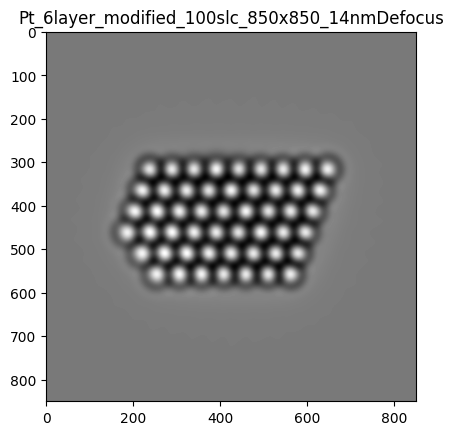

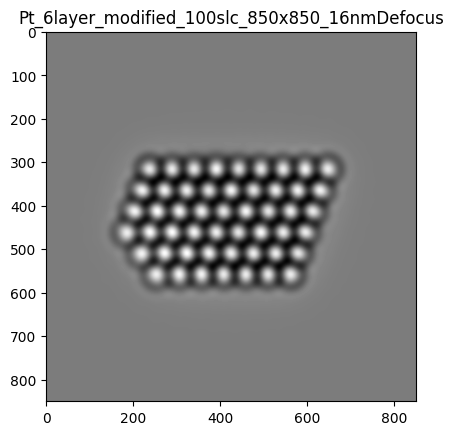

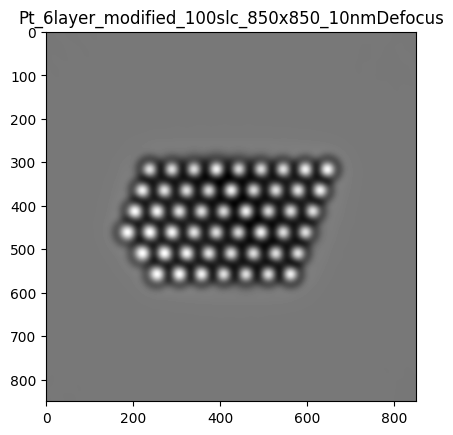

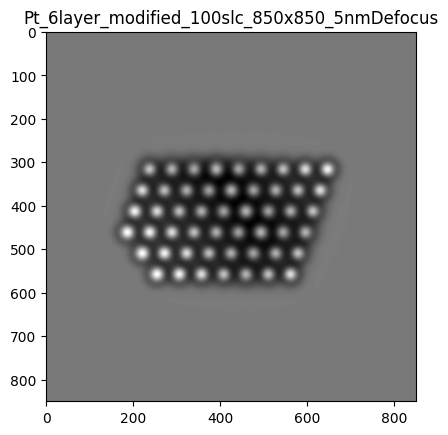

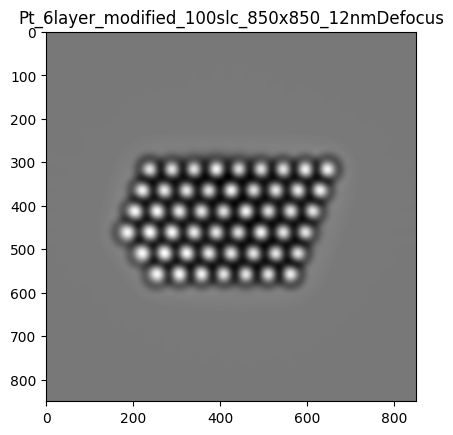

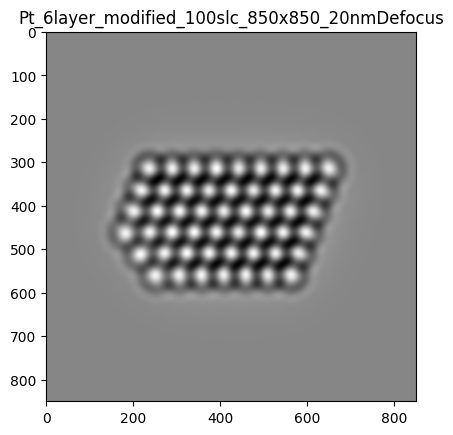

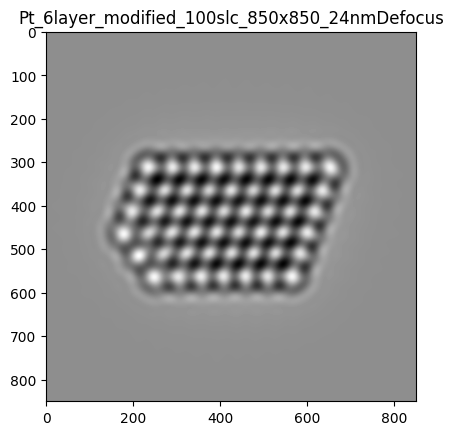

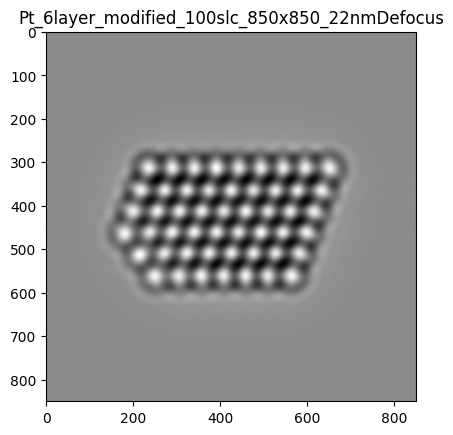

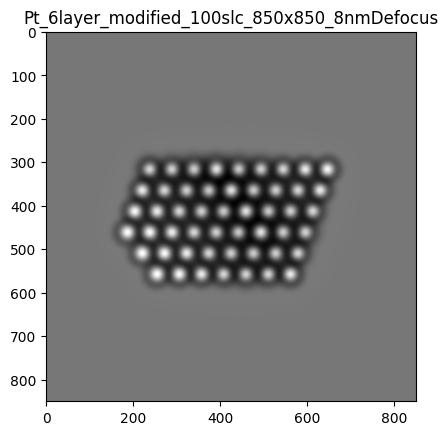

In [4]:
dr_probe.figure_generation(input_dir_img='/home/thiago/Desktop/Argonne/ingrained_test/Cif_model_examples/Cif_model_examples/test/test_new_script/class_test/output/Pt_6layer_modified/img')


Original shapes:
(336, 496)
(103, 152)
Resized shapes:
(103, 152)
(103, 152)
Dr Probe Score: 0.940989708279741


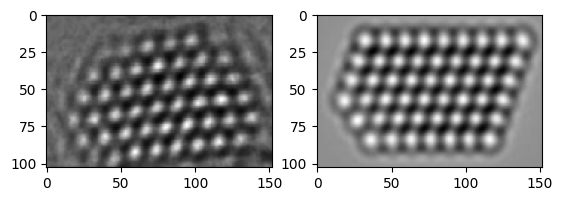

In [8]:
# Assuming you have already defined dr_probe instance and required functions

# Load the images
crp_exp_img = cv2.imread('image_exp_crop.png', cv2.IMREAD_GRAYSCALE)
dr_probe_img = cv2.imread('dr_probe_img.jpg', cv2.IMREAD_GRAYSCALE)

# Call the evaluate_model function
dr_probe.evaluate_model(crp_exp_img, dr_probe_img)


Original shapes:
(336, 496)
(103, 152)
Resized shapes:
(103, 152)
(103, 152)
Dr Probe Score: 0.940989708279741


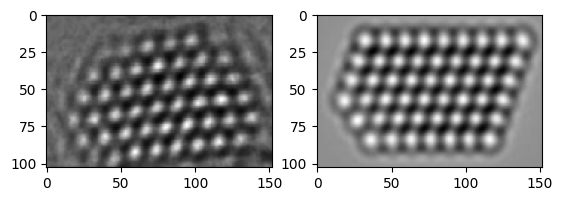

In [7]:
#You can experiment with some of the functions here, specially the rotating image function


def scale_pixels(img, mode=None):
        """
        Select a pixel scaling technique

        Args:
            mode: (string) pixel scaling technique
            rescale    :  stretch the pixel intensities so to fill the 
                            range from 0 to 1 (float64)
            center     :  enforce zero mean, unit variance (float64)
            grayscale  :  stretch the pixel intensities so to fill the 
                            range from 0 to 255 (uint8)

        Returns:
            A numpy array (either float64 or uint8) of the scaled image.
        """
        img = img.astype(np.float64)
        if mode == None:
            return img
        elif mode == "rescale":
            return ((img - img.min()) / (img.max() - img.min()) + 1e-16).astype(np.float64)
        elif mode == "center":
            return ((img - img.mean()) / (img.std())).astype(np.float64)
        elif mode == "grayscale":
            return (255 * (img - img.min()) / (img.max() - img.min()) + 1e-16).astype(
                np.uint8
            )
def score_ssim(img1, img2):
        """
        Compute the mean structural similarity index between two images

        Args:
                img1, img2: (ndarray) images

        Return:
                1 - the mean structural similarity index 
        """

        #data_range = 255  # Dynamic range of pixel values in typical images

        img1 = scale_pixels(img1, mode="rescale")  # You need to define the scale_pixels function
        img2 = scale_pixels(img2, mode="rescale")
        im_max, im_min = max(img1.max(), img2.max()), min(img1.min(), img2.min())
        return 1 - ssim(img1, img2, data_range=im_max - im_min)  # You need to import the ssim function

def evaluate_model(crp_exp_img, dr_probe_img):
    # Resize both images to the same dimensions
    crp_exp_img = cv2.resize(crp_exp_img, (103, 152))
    dr_probe_img = cv2.resize(dr_probe_img, (103, 152))

    # Get the ssim score
    dr_probe_score = score_ssim(crp_exp_img, dr_probe_img)
    
    print("Dr Probe Score: {}".format(dr_probe_score))

    # Convert images to PIL Image objects (optional)
    crp_exp_pil = Image.fromarray(crp_exp_img)
    dr_probe_pil = Image.fromarray(dr_probe_img)

    # Save images as JPG (optional)
    crp_exp_pil.save('Exp_img.jpg')
    dr_probe_pil.save('Dr_probe_img.jpg')

    # Plot the images
    f, axes = plt.subplots(1, 2)
    axes[0].imshow(crp_exp_img, cmap='gray')
    axes[1].imshow(dr_probe_img, cmap='gray')
    plt.show()


def rotate_figure(crp_exp_img, dr_probe_img):


    experimental_img = crp_exp_img
    simulated_img = dr_probe_img


    # Detect blobs in the experimental image using Difference of Gaussian (DoG)
    experimental_blobs = blob_dog(experimental_img, max_sigma=30, threshold=0.1)

    # Detect blobs in the simulated image using Difference of Gaussian (DoG)
    simulated_blobs = blob_dog(simulated_img, max_sigma=30, threshold=0.1)

    # Plot the images with detected atom positions
    plt.figure(figsize=(10, 5))


    # Detect blobs in the experimental image using Difference of Gaussian (DoG)
    experimental_blobs = blob_dog(experimental_img, max_sigma=30, threshold=0.1)
    experimental_central_point = np.mean(experimental_blobs, axis=0)[:2].astype(int)

    # Detect blobs in the simulated image using Difference of Gaussian (DoG)
    simulated_blobs = blob_dog(simulated_img, max_sigma=30, threshold=0.1)
    simulated_central_point = np.mean(simulated_blobs, axis=0)[:2].astype(int)

    # Calculate the rotation angle to align the central points
    angle = np.arctan2(experimental_central_point[1] - simulated_central_point[1],
                    experimental_central_point[0] - simulated_central_point[0])

    # Rotate the simulated image
    rotated_simulated_img = rotate(simulated_img, np.degrees(angle))

    # Plot the images with detected atom positions and overlap
    plt.figure(figsize=(12, 6))

    # Plot experimental image
    plt.subplot(1, 2, 1)
    plt.imshow(experimental_img, cmap='gray')
    plt.title('Experimental Image')
    for blob in experimental_blobs:
        y, x, _ = blob
        plt.plot(x, y)  # Red points for experimental atoms

    # Plot simulated image
    plt.subplot(1, 2, 2)
    plt.imshow(simulated_img, cmap='gray')
    plt.title('Simulated Image')
    for blob in simulated_blobs:
        y, x, _ = blob
        plt.plot(x, y, 'go', markersize=5)  # Green points for simulated atoms

    # Plot rotated simulated image
    plt.subplot(1, 3, 3)
    plt.imshow(rotated_simulated_img, cmap='gray')
    plt.title('Rotated Simulated Image')

    plt.tight_layout()
    plt.show()
    return rotated_simulated_img


def evaluate_model(crp_exp_img, dr_probe_img):
    # Ensure both images have the same dimensions
    

    print("Original shapes:")
    print(crp_exp_img.shape)
    print(dr_probe_img.shape)

    # Resize the images
    crp_exp_img = cv2.resize(crp_exp_img, (152, 103))
    dr_probe_img = cv2.resize(dr_probe_img, (152, 103))

    print("Resized shapes:")
    print(crp_exp_img.shape)
    print(dr_probe_img.shape)

    # Convert images to PIL Image objects
    crp_exp_pil = Image.fromarray(crp_exp_img)
    dr_probe_pil = Image.fromarray(dr_probe_img)

    # Save images as JPG
    crp_exp_pil.save('Exp_img.jpg')
    dr_probe_pil.save('Dr_probe_img.jpg')



    #rotated_figure=rotate_figure(crp_exp_img,dr_probe_img) #USE ROTATED IMAGE HERE


    # Get the ssim score
    dr_probe_score = score_ssim(crp_exp_img, dr_probe_img)

    print("Dr Probe Score: {}".format(dr_probe_score))

    # Plot the images
    f, axes = plt.subplots(1, 2)
    axes[0].imshow(crp_exp_img, cmap='gray')
    axes[1].imshow(dr_probe_img, cmap='gray')
    plt.show()

    

crp_exp_img = cv2.imread('image_exp_crop.png', cv2.IMREAD_GRAYSCALE)
dr_probe_img = cv2.imread('dr_probe_img.jpg', cv2.IMREAD_GRAYSCALE)

evaluate_model(crp_exp_img, dr_probe_img)